In [1]:
from DensityRatioScore.density_ratio_score import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# STEP 1: Synthetic Data Generation

We generate a synthetic dataset that has 3 classes. Points in class A and B are partially overlapping while points in Class C have no overlap with other classes.

In [2]:
rng = np.random.default_rng(42)

n_train = 300
n_test = 60
d = 8

classes = ["A", "B", "C"]

# Means chosen so A and B overlap while C is well separated.
means = {
    "A": np.zeros(d),
    "B": np.ones(d) * 1.0,
    "C": np.ones(d) * 6.0,
}

std = 1.5  # Large enough that A and B overlap noticeably.

# Training set
X_train = []
y_train = []

for cls in classes:
    X_cls = rng.normal(
        loc=means[cls],
        scale=std,
        size=(n_train // len(classes), d),
    )
    X_train.append(X_cls)
    y_train.extend([cls] * (n_train // len(classes)))

X_train = np.vstack(X_train)
y_train = np.array(y_train)

# Test set
X_test = []
y_test = []

for cls in classes:
    X_cls = rng.normal(
        loc=means[cls],
        scale=std,
        size=(n_test // len(classes), d),
    )
    X_test.append(X_cls)
    y_test.extend([cls] * (n_test // len(classes)))

X_test = np.vstack(X_test)
y_test = np.array(y_test)

test_indices = pd.MultiIndex.from_arrays(
    [
        np.arange(len(X_test)),   # sample_id
        y_test                    # true class (optional)
    ],
    names=["sample_id", "true_class"]
)

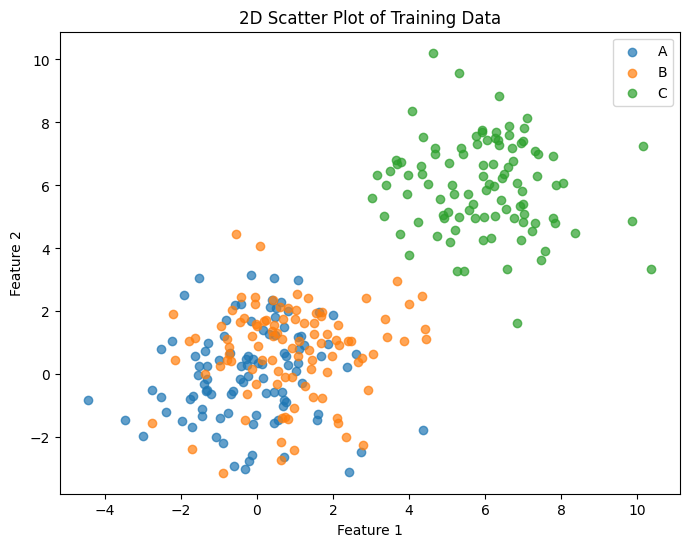

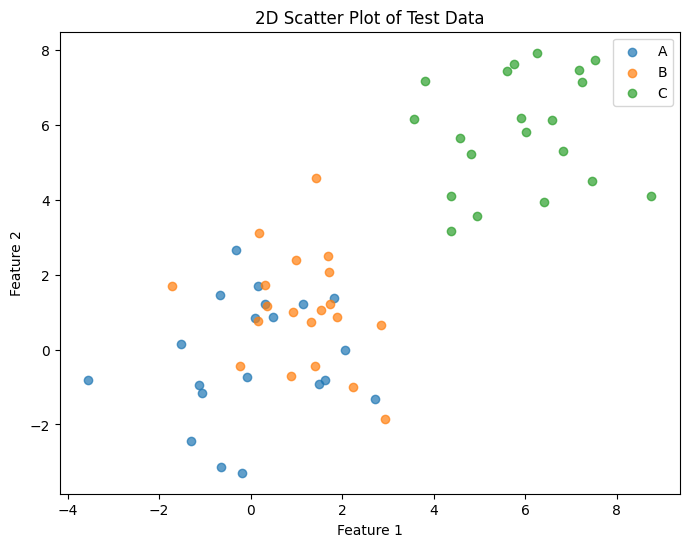

In [3]:
# Plot 2D scatter plot of the training and test data
plt.figure(figsize=(8, 6))

# Plot training data
for cls in classes:
    idx = y_train == cls
    plt.scatter(X_train[idx, 0], X_train[idx, 1], label=cls, alpha=0.7)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('2D Scatter Plot of Training Data')
plt.legend()
plt.show()

# Plot 2D scatter plot of the training and test data
plt.figure(figsize=(8, 6))

# Plot test data
for cls in classes:
    idx = y_test == cls
    plt.scatter(X_test[idx, 0], X_test[idx, 1], label=cls, alpha=0.7)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('2D Scatter Plot of Test Data')
plt.legend()
plt.show()


# Step 2: Density Ratio Score Calculation

Our goal is to calculate a score that quantifies how much a given point resembles a specific class relative to all other classes. A point belonging to the well-separated Class C should receive a high score because its nearest neighbors are predominantly other Class C points, while points from the remaining classes are much farther away. In contrast, points belonging to the overlapping Classes A and B should receive lower scores because their neighborhoods contain points from both classes, making it more difficult to distinguish one class from the other.

In [4]:
d = X_train.shape[1]

# NOTE: Normalization is very important because if you do not do this, the higher the dimensionality of the data, the higher the density ratio scores will be. 
# and thus you cannot compare scores across different dimensionalities. This is due to the formula of the density ratio score, which scales with the dimensionality of the data.
norm = True 
k = 4
eps = 1e-10
n_permutations = 10
group_keys = ['sample_id', 'true_class']
base_seed = 42

score_df = calculate_one_vs_rest_density_ratio_scores(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    test_indices=test_indices,
    classes=classes,
    d=d,
    norm=norm,
    k=k,
    eps=eps,
    n_permutations=n_permutations,
    group_keys=group_keys,
    base_seed=base_seed
)

Calculating null distribution for permutation 1/10...
Calculating null distribution for permutation 2/10...
Calculating null distribution for permutation 3/10...
Calculating null distribution for permutation 4/10...
Calculating null distribution for permutation 5/10...
Calculating null distribution for permutation 6/10...
Calculating null distribution for permutation 7/10...
Calculating null distribution for permutation 8/10...
Calculating null distribution for permutation 9/10...
Calculating null distribution for permutation 10/10...


In [5]:
score_df

,,A,B,C
sample_id,true_class,,,
0,A,3.282956,-1.412409,-47.162075
1,A,3.133893,-2.952899,-17.280503
2,A,3.479019,-1.809819,-15.126580
3,A,0.352202,1.082417,-14.302349
4,A,3.343027,-1.325156,-24.050975
5,A,0.208675,2.156298,-26.188346
6,A,1.109451,0.697552,-12.031516
7,A,2.482227,-1.583888,-16.563037
8,A,3.814178,-1.645335,-17.136184


# STEP 3: Extracting Target Class Density Ratio Scores

In score_df, we have the density ratio score relative to each class for each point. However, we are most interested in the density ratio score relative to the class that the data point actually belongs to, the target class. Thus, we extract these scores, naming them target_class_scores.

In [6]:
target_class_scores = get_target_class_scores(score_df, classes=classes, class_level='true_class')

For comparison purposes, we can calculate per-class summary statistics:

In [7]:
target_class_statistics = get_target_class_statistics(target_class_scores, class_level='true_class')

# STEP 4: Analyzing the target class scores

If we look at the mean target class scores, the Class C scores are much higher than the scores for Class A and B. This is expected because Class C points resemble other Class C points while Class A and B points resemble one another. Higher score indicates points look more like their target class; lower scores indicate points resemble other classes than their own target class. 

Text(0.5, 1.0, 'Pointwise Statistics of Density Ratio Scores by Class')

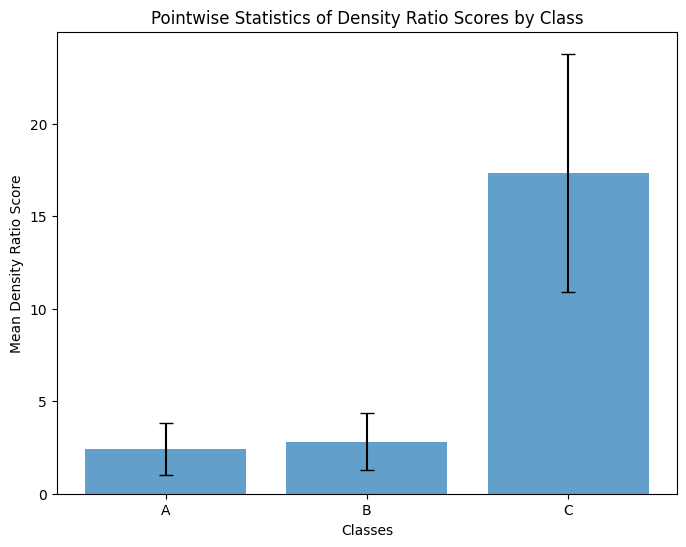

In [8]:
# Plot the pointwise statistics as bar chart with x-axis as classes and y-axis as mean score, with error bars for std deviation
plt.figure(figsize=(8, 6))
x = np.arange(len(classes))
mean_scores = target_class_statistics['mean'].values
std_scores = target_class_statistics['std'].values
plt.bar(x, mean_scores, yerr=std_scores, capsize=5, alpha=0.7)
plt.xticks(x, classes)
plt.xlabel('Classes')
plt.ylabel('Mean Density Ratio Score')
plt.title('Pointwise Statistics of Density Ratio Scores by Class')

We can also color-code each point by its target class score. We can see the points with low scores are those belonging to Class A and B.

Text(0.5, 1.0, '2D Scatter Plot of Test Data Colored by Density Ratio Scores')

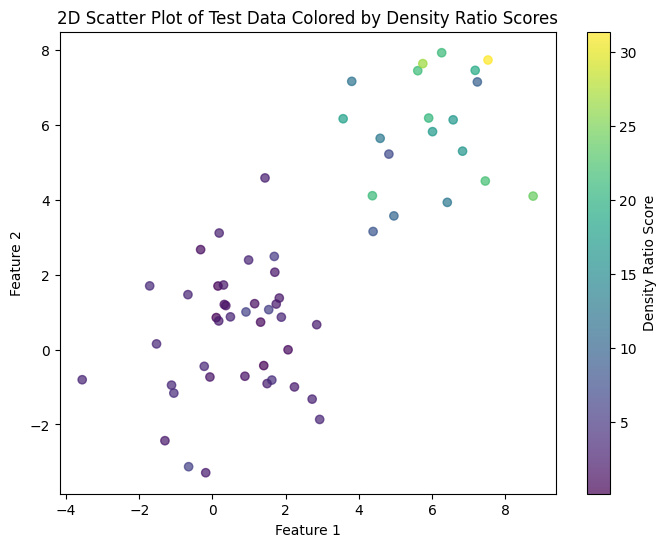

In [9]:
# Plot the 2D scatter plot of the test data colored by there true class density ratio scores (found in target_class_scores)
plt.figure(figsize=(8, 6))

assert (target_class_scores.index == test_indices).all(), "The index of target_class_scores must match the test_indices."

plt.scatter(X_test[:, 0], X_test[:, 1], c=target_class_scores['target_class_score'], cmap='viridis', alpha=0.7)
plt.colorbar(label='Density Ratio Score')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('2D Scatter Plot of Test Data Colored by Density Ratio Scores')